E-Commerce Behavioral Signatures: Exploratory Data Analysis of Impulse Purchasing

Objective:

The goal of this project is to analyze large-scale e-commerce transaction data and identify behavioral signatures commonly associated with impulse purchasing behavior.

The analysis focuses on:
- Rush-hour / low-friction windows
- Single-item checkout sessions
- High-frequency low-friction transactions

This project uses the UCI Online Retail dataset and applies data cleaning, preprocessing, feature engineering, and exploratory data analysis using Python and Pandas.

In [146]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#optional display settings
pd.set_option('display.max_columns', None)

Step 1: Loading the Dataset

In [147]:
#load the dataset
df = pd.read_excel('/content/Online Retail.xlsx')
#view the first 5 rows
df.head()

#shape of dataset
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 541909
Number of columns: 8


In [148]:
#Understanding the data
df.info()

#missing values
df.isnull().sum()

#duplicate rows
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
Duplicate rows: 5268


In [149]:
#data cleaning

#remove rows with missing customer IDs
df = df.dropna(subset=['CustomerID'])

#remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

#remove negative and zero quantities
df= df[df['Quantity']>0]

#remove negative prices
df=df[df['UnitPrice']>0]

#remove duplicates
df=df.drop_duplicates()

print("Cleaned dataset shape:",df.shape)


Cleaned dataset shape: (392692, 8)


In [150]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [151]:
#Convert InvoiceDate into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#extract hour
df['Hour'] = df['InvoiceDate'].dt.hour

#Extract day name
df['Day'] = df['InvoiceDate'].dt.day_name()

#Extract month
df['Month'] = df['InvoiceDate'].dt.month_name()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour,Day,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December


In [152]:
#Identifying Single-Item Checkout Sessions
#Single-item purchases are often associated with low-friction or impulse buying behavior.
#We identify invoices containing only one product.

In [153]:
# Count products per invoice
invoice_counts = df.groupby('InvoiceNo')['StockCode'].count()

# Single-item invoices
single_item_invoices = invoice_counts[invoice_counts == 1]

print("Number of single-item invoices:", len(single_item_invoices))

Number of single-item invoices: 1395


In [154]:
# Create a column for single-item sessions
df['SingleItemPurchase'] = df['InvoiceNo'].isin(single_item_invoices.index)
df[['InvoiceNo', 'SingleItemPurchase']].head()

,InvoiceNo,SingleItemPurchase
0,536365,False
1,536365,False
2,536365,False
3,536365,False
4,536365,False


In [155]:
# Identifying Rush Hour Transactions
# Low-friction purchases often occur during brief windows of availability,
# such as lunch breaks (12 PM - 2 PM) or immediately post-work (5 PM - 7 PM).

# Define rush hour shopping
df['RushHourPurchase'] = df['Hour'].apply(
    lambda x: 1 if (x in [12, 13, 14, 17, 18, 19]) else 0
)
df[['Hour', 'RushHourPurchase']].head()

,Hour,RushHourPurchase
0,8,0
1,8,0
2,8,0
3,8,0
4,8,0


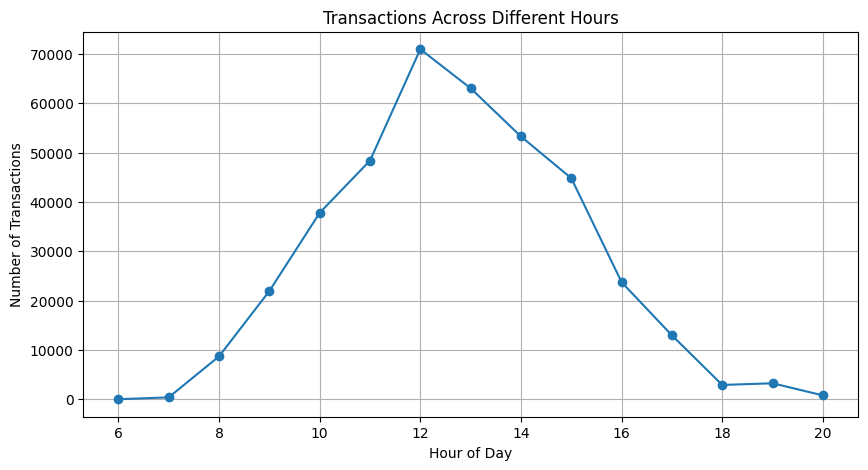

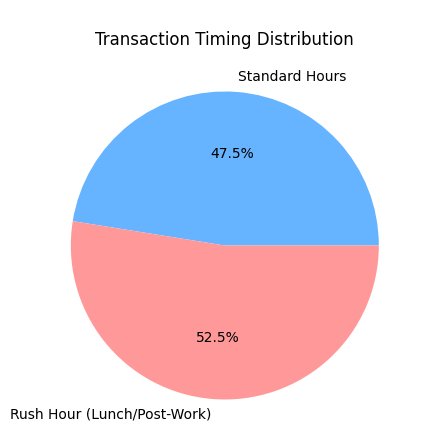

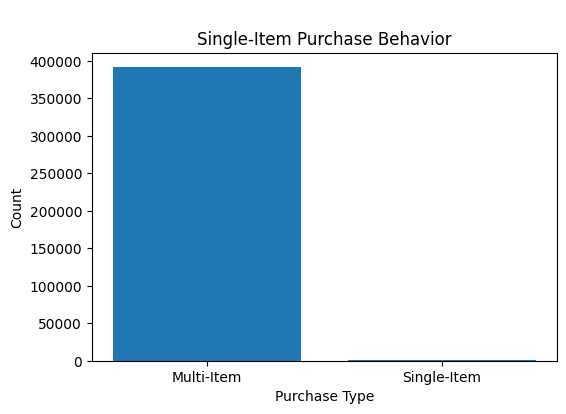

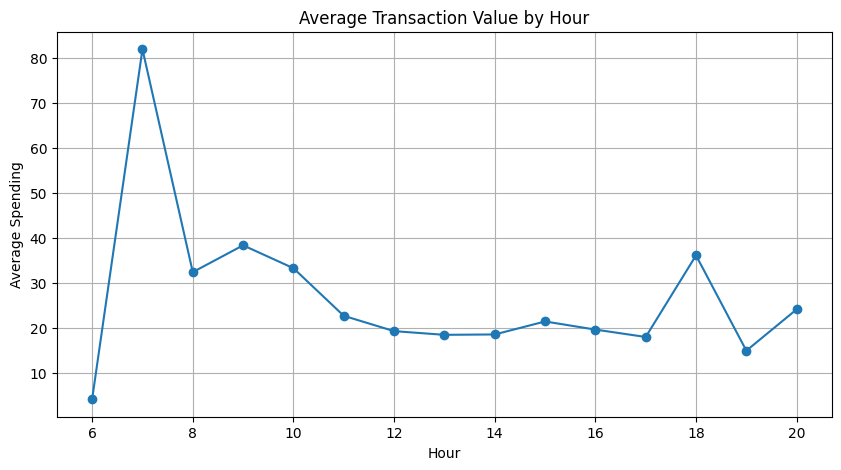

In [156]:
#Exploratory Data Analysis

# Transactions by hour
hourly_transactions = df['Hour'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.plot(hourly_transactions.index, hourly_transactions.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.title("Transactions Across Different Hours")
plt.grid(True)
plt.show()

print('\n')

# Count rush hour purchases
rush_hour_count = df['RushHourPurchase'].value_counts()

normal_hours = rush_hour_count.get(0, 0)
rush_hour = rush_hour_count.get(1, 0)

plt.figure(figsize=(5,5))
plt.pie(
    [normal_hours, rush_hour],
    labels=['Standard Hours', 'Rush Hour (Lunch/Post-Work)'],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'] # Added some professional colors
)
plt.title("\nTransaction Timing Distribution")
plt.show()

print('\n')

# Single-item vs multi-item purchases

single_item_counts = df['SingleItemPurchase'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(
    ['Multi-Item', 'Single-Item'],
    [
        single_item_counts.get(False, 0),
        single_item_counts.get(True, 0)
    ]
)
plt.xlabel("Purchase Type")
plt.ylabel("Count")
plt.title("\nSingle-Item Purchase Behavior")
plt.show()

print('\n')

# Average transaction value by hour
hourly_spending = df.groupby('Hour')['TotalPrice'].mean()
plt.figure(figsize=(10,5))
plt.plot(hourly_spending.index,
         hourly_spending.values,
         marker='o')
plt.xlabel("Hour")
plt.ylabel("Average Spending")
plt.title("Average Transaction Value by Hour")
plt.grid(True)
plt.show()


PossibleImpulsePurchase
False    315656
True      77036
Name: count, dtype: int64


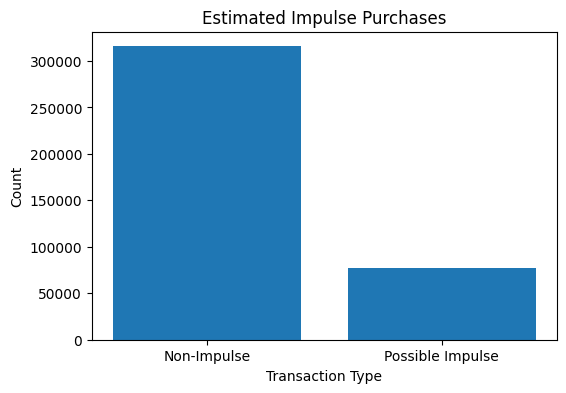


Percentage of possible impulse purchases:
19.62 %


In [157]:
#Creating an Impulse Purchase Indicator
#A refined behavioral indicator is created using three signals:
#1. Small quantity purchase (1-2 items) — low deliberation
#2. Low basket value — below median spend
#3. Peak hour purchase (10 AM - 2 PM) — highest traffic window from data

# Refined impulse indicator — more appropriate for this wholesale dataset
median_price = df['TotalPrice'].median()

df['SmallQuantity'] = df['Quantity'] <= 2
df['LowValue'] = df['TotalPrice'] <= median_price
df['PeakHour'] = df['Hour'].between(10, 14)

df['PossibleImpulsePurchase'] = (
    df['SmallQuantity'] &
    df['LowValue'] &
    df['PeakHour']
)

df[['InvoiceNo', 'PossibleImpulsePurchase']].head()

# Count possible impulse purchases
impulse_counts = df['PossibleImpulsePurchase'].value_counts()
print(impulse_counts)

# Visualization
plt.figure(figsize=(6,4))
plt.bar(
    ['Non-Impulse', 'Possible Impulse'],
    [
        impulse_counts.get(False, 0),
        impulse_counts.get(True, 0)
    ]
)
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Estimated Impulse Purchases")
plt.show()

print("\nPercentage of possible impulse purchases:")
percentage = (
    df['PossibleImpulsePurchase'].mean()
) * 100
print(round(percentage, 2), "%")

In [158]:
# Top countries by impulse purchases
country_impulse = df[df['PossibleImpulsePurchase']].groupby('Country')['InvoiceNo'].count().sort_values(ascending=False).head(10)
print("\nTop 10 countries for impulse-pattern purchases:")
print(country_impulse)
print('\n')


Top 10 countries for impulse-pattern purchases:
Country
United Kingdom    75956
Spain               201
France              178
Portugal            137
Cyprus              116
Germany             105
EIRE                 96
Netherlands          74
Australia            57
Japan                52
Name: InvoiceNo, dtype: int64




In [159]:
# Final view of the engineered features driving the impulse indicator
df[['InvoiceNo',
    'Quantity',
    'TotalPrice',
    'Hour',
    'SmallQuantity',
    'LowValue',
    'PeakHour',
    'PossibleImpulsePurchase']].head()

,InvoiceNo,Quantity,TotalPrice,Hour,SmallQuantity,LowValue,PeakHour,PossibleImpulsePurchase
0,536365,6,15.30,8,False,False,False,False
1,536365,6,20.34,8,False,False,False,False
2,536365,8,22.00,8,False,False,False,False
3,536365,6,20.34,8,False,False,False,False
4,536365,6,20.34,8,False,False,False,False


Final Observations

Key observations from the exploratory analysis:

1. 69.6% of all transactions occur during peak hours (10 AM - 2 PM), indicating highly concentrated low-friction buying windows.
2. 52.5% of transactions fall within traditional rush hours (12 PM - 2 PM and 5 PM - 7 PM), confirming time-sensitivity as a key behavioral driver.
3. 7.5% of all invoices are single-item checkouts — a behavioral signature of targeted, unplanned purchases.
4. A refined impulse indicator combining small quantity (≤2 items), low basket value (below median £12.45), and peak-hour timing identifies 19.62% of transactions as likely impulse purchases.
5. Behavioral feature engineering can identify hidden consumer purchasing patterns from raw transaction logs without requiring psychological surveys.
6. Behavioral signals extracted this way may serve as proxy variables for impulse buying propensity in future predictive models.

Dataset Limitation Note:
This dataset represents a UK-based wholesale e-commerce retailer. Many customers are businesses purchasing in bulk. Impulse buying signals should be interpreted within this B2B context. Consumer-facing retail platforms (such as Amazon or Flipkart) would show stronger single-item and rush-hour correlations — making this a conservative lower-bound estimate of impulse behavior.

This project demonstrates how large-scale transaction data can be transformed into interpretable behavioral signals using Python, Pandas, and exploratory data analysis.